# 01 — Data Cleaning

This notebook prepares the heart failure readmission dataset for EDA, statistical testing, and modeling.

Cleaning decisions:
- Drop `patient_id` because it is an identifier, not a predictor.
- Check duplicate rows and duplicate patient IDs before removing the ID column.
- Validate categorical and binary columns.
- Convert clinically impossible values to `NaN` using predefined plausible ranges.
- Keep clinically extreme but still plausible values, because they may represent high-risk patients.
- Do **not** impute in this notebook. Imputation is handled later inside the modeling pipeline to avoid data leakage.
- Save the cleaned dataset and a cleaning summary table.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt

from src.data.load import load_raw
from src.data.clean import drop_id, flag_impossible, missing_summary, RANGES
from src.viz.plots import plot_missing
from src.config import PROCESSED_DIR


## Load the raw data and check basic structure

The raw file is loaded first so duplicate rows and duplicate patient IDs can be checked before `patient_id` is dropped.


In [2]:
raw = load_raw()

raw_shape = pd.DataFrame(
    {
        'rows': [raw.shape[0]],
        'columns': [raw.shape[1]],
        'duplicate_rows': [raw.duplicated().sum()],
        'duplicate_patient_ids': [
            raw['patient_id'].duplicated().sum()
            if 'patient_id' in raw.columns
            else pd.NA
        ],
    }
)

raw_shape


,rows,columns,duplicate_rows,duplicate_patient_ids
0,3000,16,0,0


In [3]:
df = drop_id(raw)
df.shape


(3000, 15)

## Validate categorical columns

Categorical variables are checked for inconsistent spelling, capitalization, or unexpected labels.


In [4]:
categorical_cols = ['gender', 'income_level']

category_counts = []
for col in categorical_cols:
    counts = df[col].value_counts(dropna=False).rename_axis('value')
    counts = counts.reset_index(name='count')
    counts.insert(0, 'column', col)
    category_counts.append(counts)

category_counts = pd.concat(category_counts, ignore_index=True)
category_counts


,column,value,count
0,gender,Male,1508
1,gender,Female,1492
2,income_level,Low,1024
3,income_level,Medium,998
4,income_level,High,978


## Validate binary columns

Treatment indicators and the target variable should only contain 0/1 values.


In [5]:
binary_cols = ['ace_inhibitor', 'beta_blocker', 'diuretic', 'readmitted_30d']

binary_check = []
for col in binary_cols:
    observed_values = sorted(df[col].dropna().unique().tolist())
    binary_check.append(
        {
            'column': col,
            'observed_values': observed_values,
            'valid_binary': set(observed_values).issubset({0, 1}),
            'missing': df[col].isna().sum(),
        }
    )

binary_check = pd.DataFrame(binary_check)
binary_check


,column,observed_values,valid_binary,missing
0,ace_inhibitor,"[0, 1]",True,0
1,beta_blocker,"[0, 1]",True,0
2,diuretic,"[0, 1]",True,0
3,readmitted_30d,"[0, 1]",True,0


## Missingness before cleaning

This shows the missing values already present in the raw dataset after removing `patient_id`.


In [6]:
before = missing_summary(df)
before


,missing,pct
bmi,90,3.0
sodium,90,3.0
creatinine,90,3.0
age,0,0.0
gender,0,0.0
bnp,0,0.0
systolic_bp,0,0.0
heart_rate,0,0.0
ace_inhibitor,0,0.0
beta_blocker,0,0.0


## Plausible clinical ranges

Values outside these ranges are treated as impossible and converted to `NaN`. Values that are extreme but still inside these ranges are retained.


In [7]:
RANGES


{'age': (18, 110),
 'bmi': (12, 70),
 'bnp': (0, 5000),
 'sodium': (110, 160),
 'creatinine': (0.1, 15),
 'systolic_bp': (60, 250),
 'heart_rate': (30, 200)}

## Flag clinically impossible values

The cleaning step converts impossible values to missing values. These missing values will later be imputed inside the modeling pipeline after the train-test split.


In [8]:
clean = flag_impossible(df)
after = missing_summary(clean)
after


,missing,pct
creatinine,119,3.97
bmi,92,3.07
sodium,90,3.00
heart_rate,2,0.07
age,0,0.00
gender,0,0.00
bnp,0,0.00
systolic_bp,0,0.00
ace_inhibitor,0,0.00
beta_blocker,0,0.00


In [9]:
# Values newly flagged as impossible during cleaning.
newly_flagged_missing = (
    after['missing'] - before['missing']
).sort_values(ascending=False)

newly_flagged_missing


creatinine                 29
bmi                         2
heart_rate                  2
ace_inhibitor               0
adherence_score             0
age                         0
beta_blocker                0
bnp                         0
distance_to_hospital_km     0
diuretic                    0
gender                      0
income_level                0
readmitted_30d              0
sodium                      0
systolic_bp                 0
Name: missing, dtype: int64

## Missingness by readmission status

This checks whether missing values are concentrated in either the readmitted or not-readmitted group. Concentrated missingness could suggest that the missing values are not completely random.


In [10]:
missing_by_outcome = clean.isna().groupby(clean['readmitted_30d']).mean().T * 100
missing_by_outcome = missing_by_outcome.loc[missing_by_outcome.sum(axis=1) > 0]
missing_by_outcome = missing_by_outcome.round(2)
missing_by_outcome


readmitted_30d,0,1
bmi,3.06,3.08
sodium,3.28,2.59
creatinine,4.47,3.24
heart_rate,0.06,0.08


## Cleaning summary table

This table is saved so the technical report can include a clear before-and-after summary of missingness and impossible-value handling.


In [11]:
cleaning_summary = before.rename(
    columns={'missing': 'missing_before', 'pct': 'pct_before'}
).join(
    after.rename(columns={'missing': 'missing_after', 'pct': 'pct_after'}),
    how='outer',
)

cleaning_summary['newly_flagged_missing'] = (
    cleaning_summary['missing_after'] - cleaning_summary['missing_before']
)

cleaning_summary = cleaning_summary.sort_values(
    ['missing_after', 'newly_flagged_missing'],
    ascending=False,
)

cleaning_summary


,missing_before,pct_before,missing_after,pct_after,newly_flagged_missing
creatinine,90,3.0,119,3.97,29
bmi,90,3.0,92,3.07,2
sodium,90,3.0,90,3.00,0
heart_rate,0,0.0,2,0.07,2
ace_inhibitor,0,0.0,0,0.00,0
adherence_score,0,0.0,0,0.00,0
age,0,0.0,0,0.00,0
beta_blocker,0,0.0,0,0.00,0
bnp,0,0.0,0,0.00,0
distance_to_hospital_km,0,0.0,0,0.00,0


## Missingness indicator dataset

The main cleaned file does not include missingness indicators. However, this optional version can be useful if the modeling team wants to test whether missingness itself helps predict readmission.


In [12]:
indicator_cols = [
    col for col in ['bmi', 'sodium', 'creatinine', 'heart_rate']
    if col in clean.columns and clean[col].isna().any()
]

clean_with_indicators = clean.copy()
for col in indicator_cols:
    clean_with_indicators[f'{col}_missing'] = clean_with_indicators[col].isna().astype(int)

clean_with_indicators.filter(like='_missing').sum().sort_values(ascending=False)


creatinine_missing    119
bmi_missing            92
sodium_missing         90
heart_rate_missing      2
dtype: int64

## Visualize remaining missingness


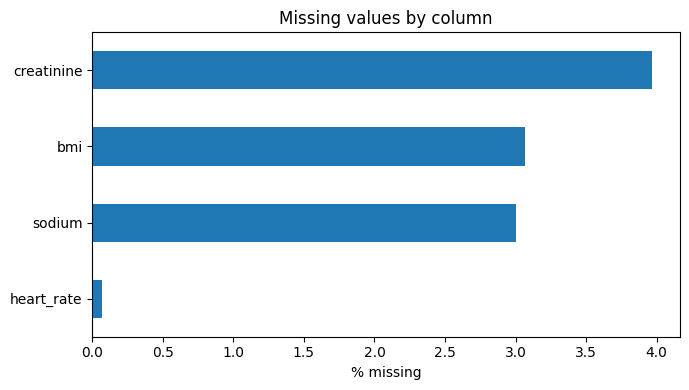

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_missing(clean, ax=ax)
fig.tight_layout()


## Save processed files

`cleaned.csv` is the main modeling dataset. Imputation should still happen later inside the modeling pipeline.


In [14]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

clean.to_csv(PROCESSED_DIR / 'cleaned.csv', index=False)
cleaning_summary.to_csv(PROCESSED_DIR / 'cleaning_summary.csv')
category_counts.to_csv(PROCESSED_DIR / 'category_value_counts.csv', index=False)
binary_check.to_csv(PROCESSED_DIR / 'binary_validation.csv', index=False)
missing_by_outcome.to_csv(PROCESSED_DIR / 'missingness_by_outcome.csv')
clean_with_indicators.to_csv(
    PROCESSED_DIR / 'cleaned_with_missing_indicators.csv',
    index=False,
)

clean.shape


(3000, 15)